https://youtu.be/f02JPNZmrrc

## TUTORIAL 3: MORPHOLOGY ANALYSIS - OSMOTIC STRESS EFFECTS

**GOAL:**
Determine if osmotic stress significantly affects cell morphology in 3D cancer
spheroids using statistical methods.

**RESEARCH QUESTION:**
Does hypertonic medium alter cell shape, size, and chromatin organization
compared to isotonic conditions?

**DATASET:** Fig-3 (2,062 cells, Isotonic vs Hypertonic) - Download from the below link

Link to the original paper: https://www.nature.com/articles/s41592-025-02685-4

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind, levene, shapiro
import warnings

warnings.filterwarnings("ignore")

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


### LOAD DATA


Let's load the Fig-3 dataset which contains the osmotic stress experiment.
This dataset has cells from isotonic (normal) and hypertonic (stressed)
conditions across 2 wells and 6 imaging fields.


In [ ]:
def load_fig3_data(data_path):
    """
    Load Figure 3 dataset containing osmotic stress experiment data.

    Args:
        data_path: Path to the directory containing Excel files

    Returns:
        DataFrame with osmotic stress experiment data
    """
    file_path = f"{data_path}/Fig-3-41592_2025_2685_MOESM10_ESM.xlsx"

    print(f"\n{'='*70}")
    print("LOADING OSMOTIC STRESS DATASET")
    print(f"{'='*70}")

    df = pd.read_excel(file_path, sheet_name='Cell statistics')

    print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\nConditions: {df['Condition'].unique()}")
    print(f"\nSample sizes:")
    print(df['Condition'].value_counts())

    return df

# Execute: Load the data
data_path = "/content/drive/MyDrive/ColabNotebooks/data/3D_Organoid_Analysis"
df_fig3 = load_fig3_data(data_path)


LOADING OSMOTIC STRESS DATASET
Dataset loaded: 2062 rows × 11 columns

Conditions: ['Isotonic' 'Hypertonic']

Sample sizes:
Condition
Isotonic      1300
Hypertonic     762
Name: count, dtype: int64


### PART 1: HYPOTHESIS AND SETUP


Before diving into analysis, let's clearly state our hypothesis and understand
the experimental design.

HYPOTHESIS:
- H0 (Null): Hypertonic medium has no effect on cell morphology
- H1 (Alternative): Hypertonic medium causes significant changes in cell volume,
                   shape, and chromatin organization

EXPERIMENTAL DESIGN:
- 2 conditions: Isotonic (control) vs Hypertonic (stressed)
- 2 wells total (1 per condition)
- 6 imaging fields per condition
- Total cells: ~2,062 (unbalanced between conditions)


In [ ]:
def summarize_experimental_design(df):
    """
    Summarize the experimental design and sample structure.

    Args:
        df: DataFrame containing the osmotic stress data
    """
    print(f"\n{'='*70}")
    print("EXPERIMENTAL DESIGN SUMMARY")
    print(f"{'='*70}")

    print("\n📊 SAMPLE STRUCTURE:")
    print(f"Total cells: {len(df)}")

    print("\n📊 BREAKDOWN BY CONDITION:")
    for condition in df['Condition'].unique():
        condition_df = df[df['Condition'] == condition]
        n_wells = condition_df['Well'].nunique()
        n_fields = condition_df['Field'].nunique()
        n_cells = len(condition_df)

        print(f"\n{condition}:")
        print(f"  - Wells: {n_wells}")
        print(f"  - Fields: {n_fields}")
        print(f"  - Total cells: {n_cells}")

    # Get numeric feature columns
    feature_cols = [col for col in df.columns if 'Value of' in col]

    print(f"\n📊 MORPHOLOGY FEATURES TO ANALYZE ({len(feature_cols)}):")
    for col in feature_cols:
        # Clean up column name for display
        feature_name = col.replace('Value of Default_', '').replace('_', ' ')
        print(f"  - {feature_name}")

    return feature_cols

# Execute: Summarize design
feature_columns = summarize_experimental_design(df_fig3)




EXPERIMENTAL DESIGN SUMMARY

📊 SAMPLE STRUCTURE:
Total cells: 2062

📊 BREAKDOWN BY CONDITION:

Isotonic:
  - Wells: 1
  - Fields: 6
  - Total cells: 1300

Hypertonic:
  - Wells: 1
  - Fields: 6
  - Total cells: 762

📊 MORPHOLOGY FEATURES TO ANALYZE (5):
  - nuclei dist to border ratio
  - cell elongation
  - cell roundness
  - cell volume μm3
  - CV



### PART 2: VISUAL COMPARISON


We are all humans, I assume, so visual comparison is critical before statistical testing. Let's create
side-by-side comparisons to see the distributions of each morphology feature
between isotonic and hypertonic conditions.


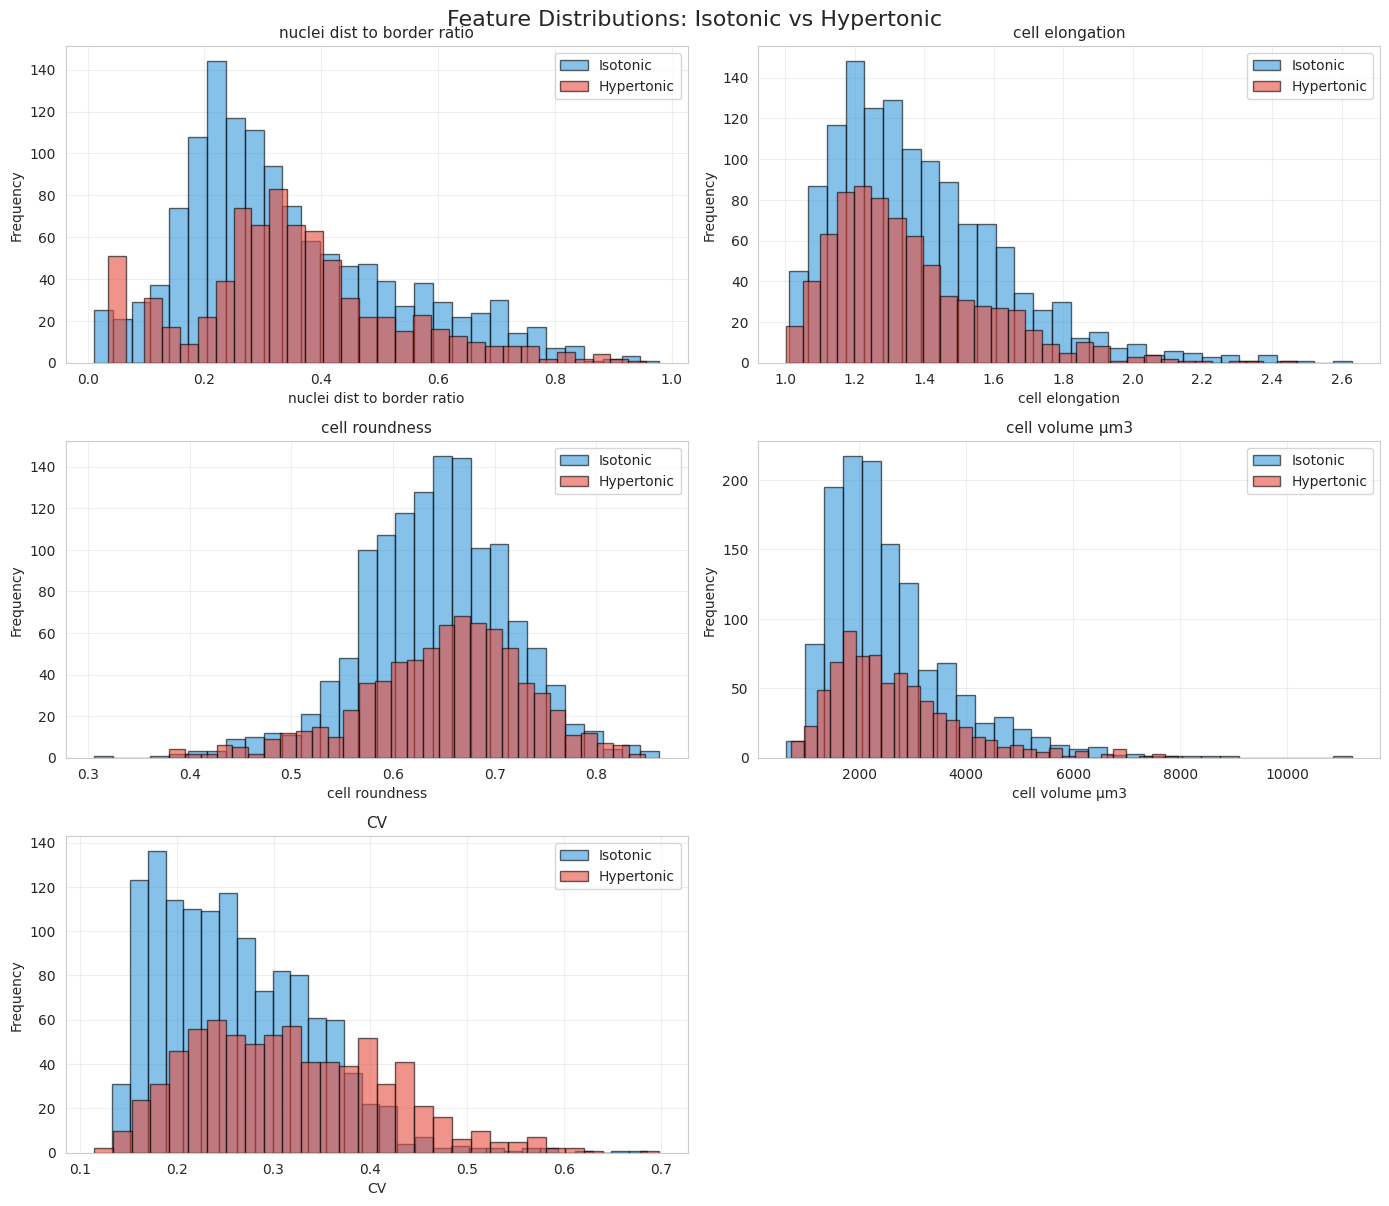

✓ Histogram comparison complete


In [ ]:
def plot_feature_comparison_histograms(df, feature_cols, condition_col='Condition'):
    """
    Create side-by-side histograms comparing distributions between conditions.

    Args:
        df: DataFrame with data
        feature_cols: List of feature column names to plot
        condition_col: Column name containing condition labels
    """
    n_features = len(feature_cols)
    n_cols = 2
    n_rows = (n_features + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    axes = axes.flatten()

    conditions = df[condition_col].unique()
    colors = ['#3498db', '#e74c3c']  # Blue for isotonic, red for hypertonic

    for idx, col in enumerate(feature_cols):
        ax = axes[idx]

        for condition, color in zip(conditions, colors):
            data = df[df[condition_col] == condition][col].dropna()
            ax.hist(data, bins=30, alpha=0.6, label=condition, color=color, edgecolor='black')

        # Clean up feature name for title
        feature_name = col.replace('Value of Default_', '').replace('_', ' ')
        ax.set_xlabel(feature_name, fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)
        ax.set_title(feature_name, fontsize=11)
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for idx in range(n_features, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.suptitle('Feature Distributions: Isotonic vs Hypertonic',
                 fontsize=16, y=1.001)
    plt.show()

    print("✓ Histogram comparison complete")

# Execute: Plot histograms
plot_feature_comparison_histograms(df_fig3, feature_columns)

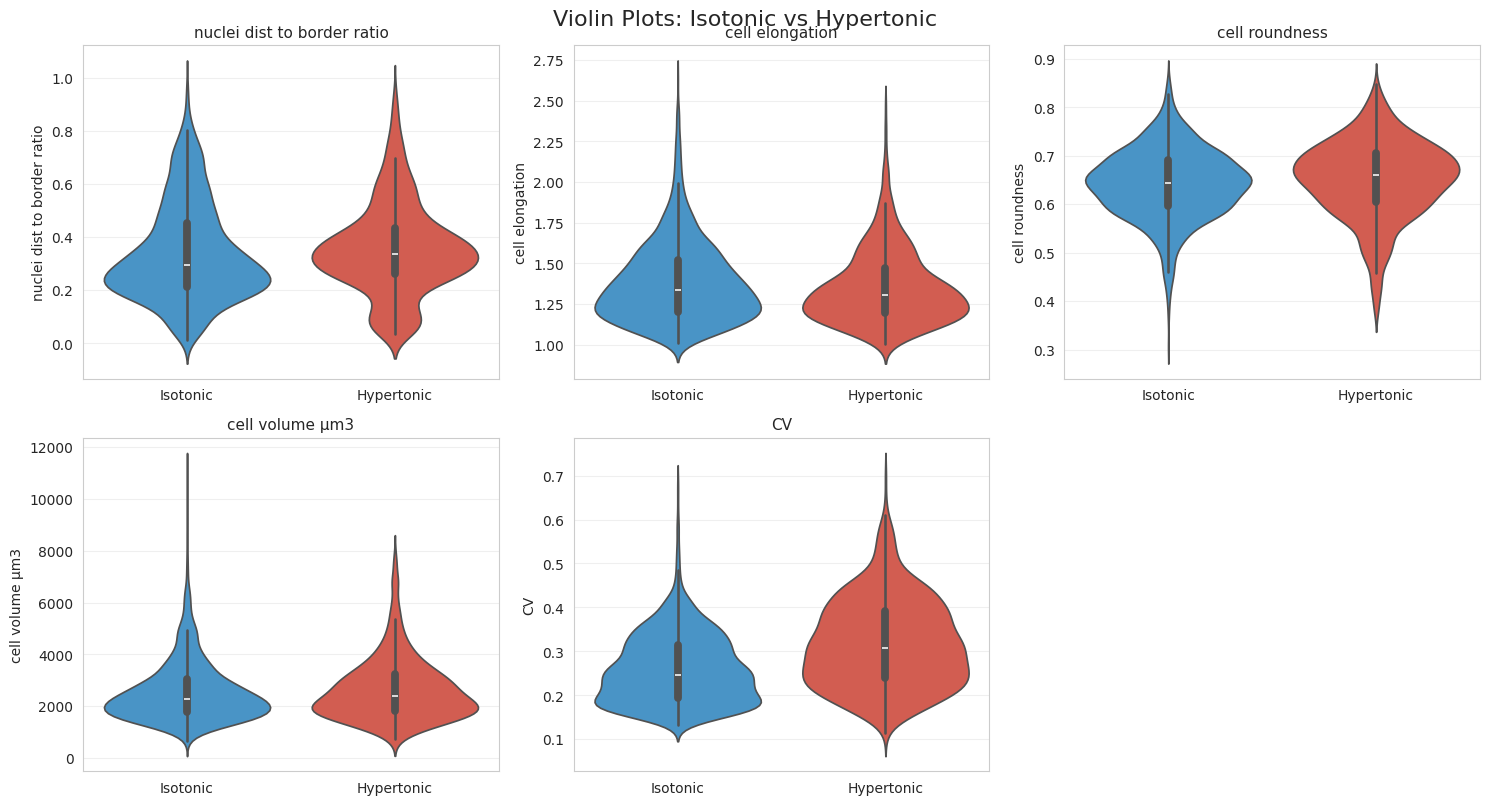

✓ Violin plot comparison complete


In [ ]:
def plot_feature_comparison_violins(df, feature_cols, condition_col='Condition'):
    """
    Create violin plots to compare distributions with embedded statistics.

    Args:
        df: DataFrame with data
        feature_cols: List of feature column names to plot
        condition_col: Column name containing condition labels
    """
    n_features = len(feature_cols)
    n_cols = 3
    n_rows = (n_features + 2) // 3

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(feature_cols):
        ax = axes[idx]

        # Create violin plot
        sns.violinplot(data=df, x=condition_col, y=col, ax=ax,
                      palette=['#3498db', '#e74c3c'], inner='box')

        # Clean up feature name
        feature_name = col.replace('Value of Default_', '').replace('_', ' ')
        ax.set_xlabel('')
        ax.set_ylabel(feature_name, fontsize=10)
        ax.set_title(feature_name, fontsize=11)
        ax.grid(True, alpha=0.3, axis='y')

    # Hide unused subplots
    for idx in range(n_features, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.suptitle('Violin Plots: Isotonic vs Hypertonic',
                 fontsize=16, y=1.001)
    plt.show()

    print("✓ Violin plot comparison complete")

# Execute: Plot violins
plot_feature_comparison_violins(df_fig3, feature_columns)

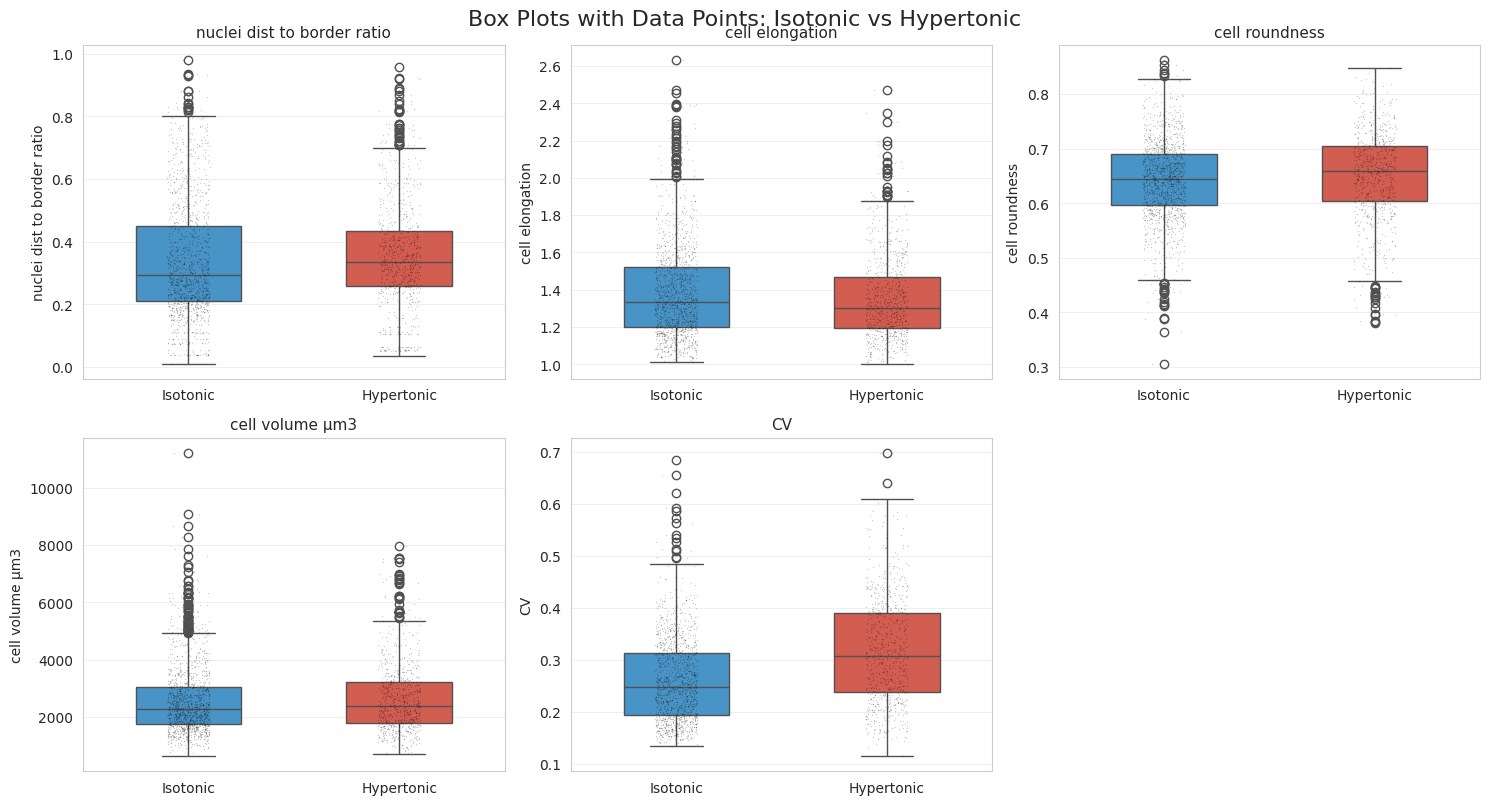

✓ Box plot comparison complete


In [ ]:
def plot_feature_comparison_boxes(df, feature_cols, condition_col='Condition'):
    """
    Create box plots with individual data points overlaid.

    Args:
        df: DataFrame with data
        feature_cols: List of feature column names to plot
        condition_col: Column name containing condition labels
    """
    n_features = len(feature_cols)
    n_cols = 3
    n_rows = (n_features + 2) // 3

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(feature_cols):
        ax = axes[idx]

        # Create box plot
        sns.boxplot(data=df, x=condition_col, y=col, ax=ax,
                   palette=['#3498db', '#e74c3c'], width=0.5)

        # Overlay strip plot with reduced point size
        sns.stripplot(data=df, x=condition_col, y=col, ax=ax,
                     color='black', alpha=0.2, size=1, jitter=True)

        # Clean up feature name
        feature_name = col.replace('Value of Default_', '').replace('_', ' ')
        ax.set_xlabel('')
        ax.set_ylabel(feature_name, fontsize=10)
        ax.set_title(feature_name, fontsize=11)
        ax.grid(True, alpha=0.3, axis='y')

    # Hide unused subplots
    for idx in range(n_features, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.suptitle('Box Plots with Data Points: Isotonic vs Hypertonic',
                 fontsize=16, y=1.001)
    plt.show()

    print("✓ Box plot comparison complete")

# Execute: Plot boxes
plot_feature_comparison_boxes(df_fig3, feature_columns)



### PART 3: STATISTICAL TESTING


Now let's perform rigorous statistical testing. We'll:
1. Check assumptions (normality and equal variance)
2. Choose appropriate test based on assumptions
3. Calculate effect sizes (Cohen's d)
4. Apply multiple testing correction


In [ ]:
def check_normality(df, feature_cols, condition_col='Condition', sample_size=5000):
    """
    Check normality assumption using Shapiro-Wilk test.
    Note: For large samples, use a subset to avoid always rejecting normality.

    Args:
        df: DataFrame with data
        feature_cols: List of features to test
        condition_col: Column with condition labels
        sample_size: Maximum sample size for Shapiro test

    Returns:
        DataFrame with normality test results
    """
    print(f"\n{'='*70}")
    print("CHECKING NORMALITY ASSUMPTION")
    print(f"{'='*70}")

    results = []

    for col in feature_cols:
        for condition in df[condition_col].unique():
            data = df[df[condition_col] == condition][col].dropna()

            # Use subset if sample is large
            if len(data) > sample_size:
                data = data.sample(sample_size, random_state=42)

            # Shapiro-Wilk test
            stat, p_value = shapiro(data)
            is_normal = p_value > 0.05

            results.append({
                'Feature': col.replace('Value of Default_', ''),
                'Condition': condition,
                'P_value': p_value,
                'Is_Normal': 'Yes' if is_normal else 'No'
            })

    results_df = pd.DataFrame(results)

    # Summary
    print(f"\nNormality test results (α = 0.05):")
    print(f"Features passing normality: {(results_df['Is_Normal'] == 'Yes').sum()} / {len(results_df)}")

    return results_df

# Execute: Check normality
normality_results = check_normality(df_fig3, feature_columns)
print("\n", normality_results)



CHECKING NORMALITY ASSUMPTION

Normality test results (α = 0.05):
Features passing normality: 0 / 10

                        Feature   Condition       P_value Is_Normal
0  nuclei_dist_to_border_ratio    Isotonic  1.039567e-21        No
1  nuclei_dist_to_border_ratio  Hypertonic  1.229584e-12        No
2              cell_elongation    Isotonic  4.028820e-26        No
3              cell_elongation  Hypertonic  3.492422e-20        No
4               cell_roundness    Isotonic  4.456999e-07        No
5               cell_roundness  Hypertonic  1.110083e-08        No
6              cell_volume_μm3    Isotonic  8.951750e-32        No
7              cell_volume_μm3  Hypertonic  7.566393e-22        No
8                           CV    Isotonic  2.245836e-22        No
9                           CV  Hypertonic  4.991564e-10        No


In [ ]:
def check_equal_variance(df, feature_cols, condition_col='Condition'):
    """
    Check equal variance assumption using Levene's test.

    Args:
        df: DataFrame with data
        feature_cols: List of features to test
        condition_col: Column with condition labels

    Returns:
        DataFrame with variance test results
    """
    print(f"\n{'='*70}")
    print("CHECKING EQUAL VARIANCE ASSUMPTION")
    print(f"{'='*70}")

    results = []
    conditions = df[condition_col].unique()

    for col in feature_cols:
        groups = [df[df[condition_col] == cond][col].dropna() for cond in conditions]

        # Levene's test
        stat, p_value = levene(*groups)
        equal_var = p_value > 0.05

        results.append({
            'Feature': col.replace('Value of Default_', ''),
            'P_value': p_value,
            'Equal_Variance': 'Yes' if equal_var else 'No'
        })

    results_df = pd.DataFrame(results)

    # Summary
    print(f"\nEqual variance test results (α = 0.05):")
    print(f"Features with equal variance: {(results_df['Equal_Variance'] == 'Yes').sum()} / {len(results_df)}")

    return results_df

# Execute: Check equal variance
variance_results = check_equal_variance(df_fig3, feature_columns)
print("\n", variance_results)



CHECKING EQUAL VARIANCE ASSUMPTION

Equal variance test results (α = 0.05):
Features with equal variance: 1 / 5

                        Feature       P_value Equal_Variance
0  nuclei_dist_to_border_ratio  1.641849e-02             No
1              cell_elongation  1.243468e-02             No
2               cell_roundness  5.255280e-03             No
3              cell_volume_μm3  1.541121e-01            Yes
4                           CV  2.134326e-13             No


In [ ]:
def calculate_cohens_d(group1, group2):
    """
    Calculate Cohen's d effect size.

    Interpretation:
    - Small effect: d ~ 0.2
    - Medium effect: d ~ 0.5
    - Large effect: d ~ 0.8

    Args:
        group1, group2: Arrays of values for two groups

    Returns:
        Cohen's d value
    """
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)

    # Pooled standard deviation
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))

    # Cohen's d
    d = (np.mean(group1) - np.mean(group2)) / pooled_std

    return d


def perform_statistical_tests(df, feature_cols, condition_col='Condition'):
    """
    Perform statistical tests comparing conditions for each feature.
    Uses t-test if assumptions met, otherwise Mann-Whitney U test.
    Calculates effect sizes and applies Bonferroni correction.

    Args:
        df: DataFrame with data
        feature_cols: List of features to test
        condition_col: Column with condition labels

    Returns:
        DataFrame with complete test results
    """
    print(f"\n{'='*70}")
    print("PERFORMING STATISTICAL TESTS")
    print(f"{'='*70}")

    conditions = sorted(df[condition_col].unique())
    group1_name, group2_name = conditions[0], conditions[1]

    results = []

    for col in feature_cols:
        # Get data for both groups
        group1 = df[df[condition_col] == group1_name][col].dropna()
        group2 = df[df[condition_col] == group2_name][col].dropna()

        # Descriptive statistics
        mean1, mean2 = group1.mean(), group2.mean()
        std1, std2 = group1.std(), group2.std()
        n1, n2 = len(group1), len(group2)

        # Check assumptions
        _, p_norm1 = shapiro(group1.sample(min(5000, len(group1)), random_state=42))
        _, p_norm2 = shapiro(group2.sample(min(5000, len(group2)), random_state=42))
        _, p_var = levene(group1, group2)

        assumptions_met = (p_norm1 > 0.05) and (p_norm2 > 0.05) and (p_var > 0.05)

        # Choose test
        if assumptions_met:
            stat, p_value = ttest_ind(group1, group2)
            test_used = "t-test"
        else:
            stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')
            test_used = "Mann-Whitney U"

        # Calculate effect size (Cohen's d)
        cohens_d = calculate_cohens_d(group1, group2)

        # Effect size interpretation
        if abs(cohens_d) < 0.2:
            effect_magnitude = "Negligible"
        elif abs(cohens_d) < 0.5:
            effect_magnitude = "Small"
        elif abs(cohens_d) < 0.8:
            effect_magnitude = "Medium"
        else:
            effect_magnitude = "Large"

        results.append({
            'Feature': col.replace('Value of Default_', ''),
            f'{group1_name}_Mean': mean1,
            f'{group1_name}_SD': std1,
            f'{group1_name}_N': n1,
            f'{group2_name}_Mean': mean2,
            f'{group2_name}_SD': std2,
            f'{group2_name}_N': n2,
            'Mean_Difference': mean2 - mean1,
            'Test_Used': test_used,
            'P_value': p_value,
            'Cohens_d': cohens_d,
            'Effect_Size': effect_magnitude
        })

    results_df = pd.DataFrame(results)

    # Apply Bonferroni correction
    alpha = 0.05
    bonferroni_threshold = alpha / len(feature_cols)
    results_df['Significant_Bonferroni'] = results_df['P_value'] < bonferroni_threshold

    print(f"\nStatistical tests complete")
    print(f"Bonferroni-corrected significance threshold: {bonferroni_threshold:.4f}")
    print(f"Significant features: {results_df['Significant_Bonferroni'].sum()} / {len(feature_cols)}")

    return results_df

# Execute: Perform tests
test_results = perform_statistical_tests(df_fig3, feature_columns)




PERFORMING STATISTICAL TESTS

Statistical tests complete
Bonferroni-corrected significance threshold: 0.0100
Significant features: 4 / 5


In [ ]:
def display_test_results_table(results_df):
    """
    Display formatted results table showing key statistics.

    Args:
        results_df: DataFrame with test results
    """
    print(f"\n{'='*70}")
    print("COMPLETE STATISTICAL RESULTS")
    print(f"{'='*70}\n")

    # Select key columns for display
    display_cols = ['Feature', 'Mean_Difference', 'P_value', 'Cohens_d',
                   'Effect_Size', 'Test_Used', 'Significant_Bonferroni']

    display_df = results_df[display_cols].copy()

    # Format numeric columns
    display_df['Mean_Difference'] = display_df['Mean_Difference'].round(3)
    display_df['P_value'] = display_df['P_value'].apply(lambda x: f"{x:.4f}")
    display_df['Cohens_d'] = display_df['Cohens_d'].round(3)

    print(display_df.to_string(index=False))

    # Save to CSV
    results_df.to_csv('osmotic_stress_statistical_results.csv', index=False)
    print("\n✓ Full results saved to 'osmotic_stress_statistical_results.csv'")

# Execute: Display results
display_test_results_table(test_results)



COMPLETE STATISTICAL RESULTS

                    Feature  Mean_Difference P_value  Cohens_d Effect_Size      Test_Used  Significant_Bonferroni
nuclei_dist_to_border_ratio           -0.015  0.0002     0.081  Negligible Mann-Whitney U                    True
            cell_elongation            0.033  0.0060    -0.135  Negligible Mann-Whitney U                    True
             cell_roundness           -0.009  0.0005     0.113  Negligible Mann-Whitney U                    True
            cell_volume_μm3          -86.168  0.0598     0.072  Negligible Mann-Whitney U                   False
                         CV           -0.058  0.0000     0.663      Medium Mann-Whitney U                    True

✓ Full results saved to 'osmotic_stress_statistical_results.csv'


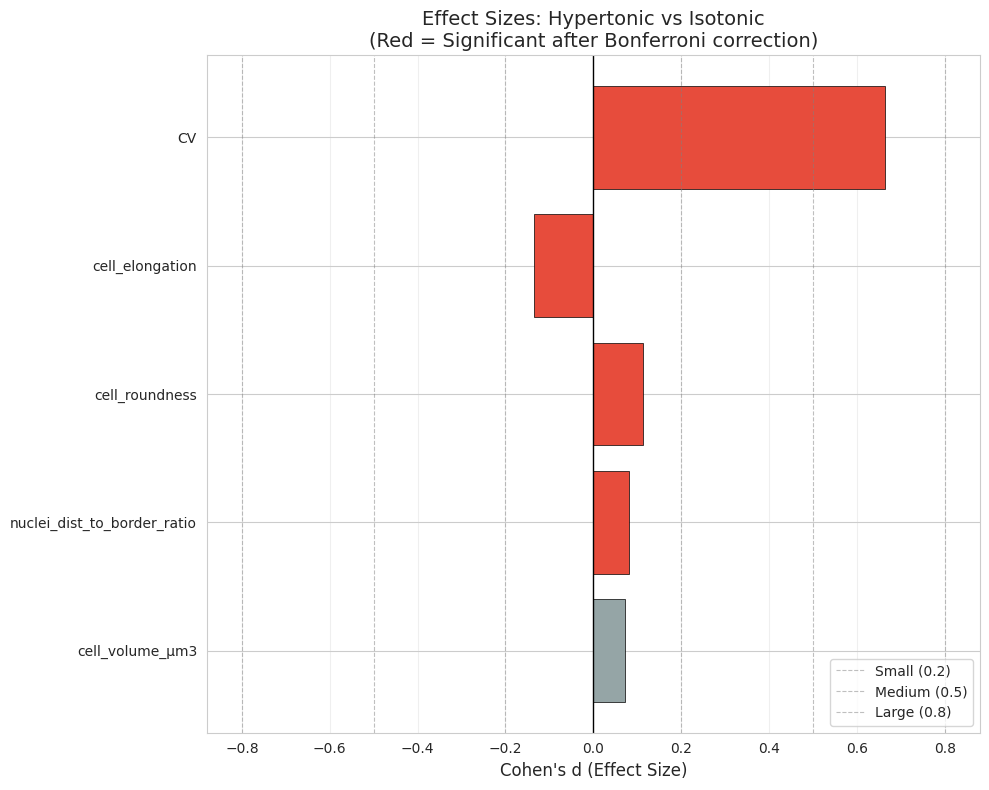

✓ Effect size visualization complete


In [ ]:
def plot_effect_sizes(results_df):
    """
    Visualize effect sizes for all features with significance indicators.

    Args:
        results_df: DataFrame with test results
    """
    # Sort by absolute effect size
    plot_df = results_df.sort_values('Cohens_d', key=abs, ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))

    # Color by significance
    colors = ['#e74c3c' if sig else '#95a5a6'
             for sig in plot_df['Significant_Bonferroni']]

    # Create horizontal bar plot
    y_pos = np.arange(len(plot_df))
    ax.barh(y_pos, plot_df['Cohens_d'], color=colors, edgecolor='black', linewidth=0.5)

    # Add reference lines for effect size thresholds
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.axvline(x=0.2, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='Small (0.2)')
    ax.axvline(x=-0.2, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='Medium (0.5)')
    ax.axvline(x=-0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='Large (0.8)')
    ax.axvline(x=-0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_df['Feature'])
    ax.set_xlabel("Cohen's d (Effect Size)", fontsize=12)
    ax.set_title("Effect Sizes: Hypertonic vs Isotonic\n(Red = Significant after Bonferroni correction)",
                fontsize=14)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

    print("✓ Effect size visualization complete")

# Execute: Plot effect sizes
plot_effect_sizes(test_results)

### PART 4: FIELD-LEVEL VARIATION


Let's examine whether the effects are consistent across imaging fields.
This helps us understand if we're seeing true biological effects or
technical artifacts from specific imaging regions.

In [ ]:
def analyze_field_variation(df, feature_cols, condition_col='Condition', field_col='Field'):
    """
    Analyze how features vary across imaging fields within each condition.

    Args:
        df: DataFrame with data
        feature_cols: List of features to analyze
        condition_col: Column with condition labels
        field_col: Column with field identifiers
    """
    print(f"\n{'='*70}")
    print("ANALYZING FIELD-LEVEL VARIATION")
    print(f"{'='*70}")

    # Calculate mean per field for each feature
    field_means = df.groupby([condition_col, field_col])[feature_cols].mean().reset_index()

    # Calculate coefficient of variation across fields for each condition
    cv_results = []

    for col in feature_cols:
        for condition in df[condition_col].unique():
            field_values = field_means[field_means[condition_col] == condition][col]
            mean_val = field_values.mean()
            std_val = field_values.std()
            cv = (std_val / mean_val) * 100 if mean_val != 0 else 0

            cv_results.append({
                'Feature': col.replace('Value of Default_', ''),
                'Condition': condition,
                'Field_CV_%': cv,
                'Field_Mean': mean_val,
                'Field_SD': std_val
            })

    cv_df = pd.DataFrame(cv_results)

    print("\nField-to-field variability (Coefficient of Variation %):")
    print(cv_df.pivot(index='Feature', columns='Condition', values='Field_CV_%').round(2))

    return field_means, cv_df

# Execute: Analyze field variation
field_means, field_cv = analyze_field_variation(df_fig3, feature_columns)



ANALYZING FIELD-LEVEL VARIATION

Field-to-field variability (Coefficient of Variation %):
Condition                    Hypertonic  Isotonic
Feature                                          
CV                                 7.98      8.26
cell_elongation                    3.31      1.24
cell_roundness                     2.14      1.09
cell_volume_μm3                   15.96      4.89
nuclei_dist_to_border_ratio       12.71      5.06



Generating field consistency plots for each feature...


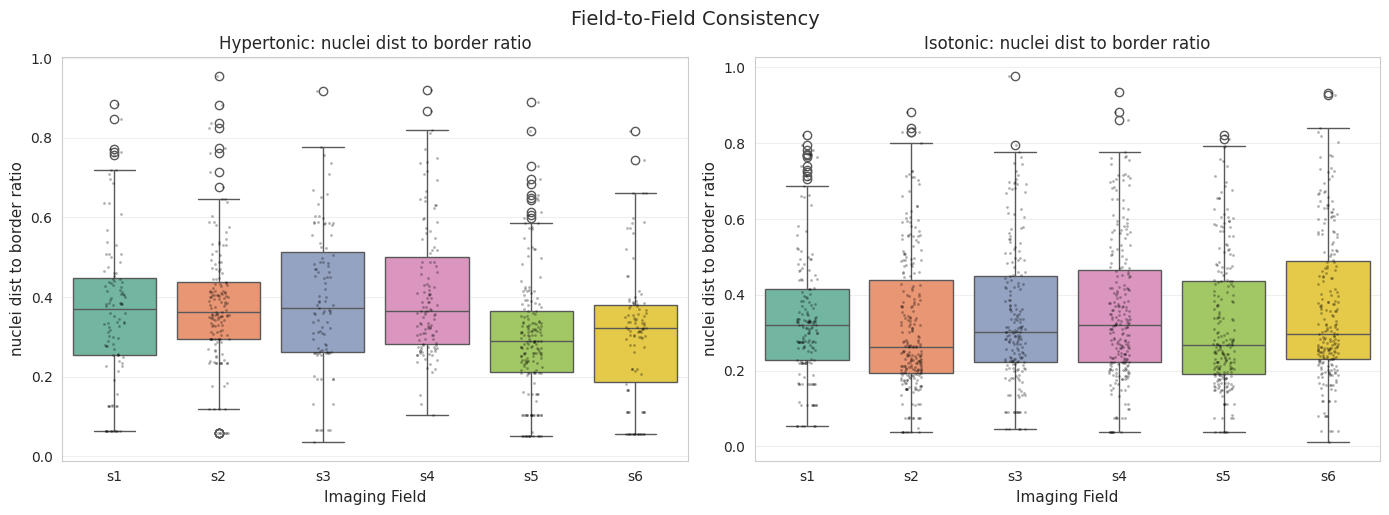

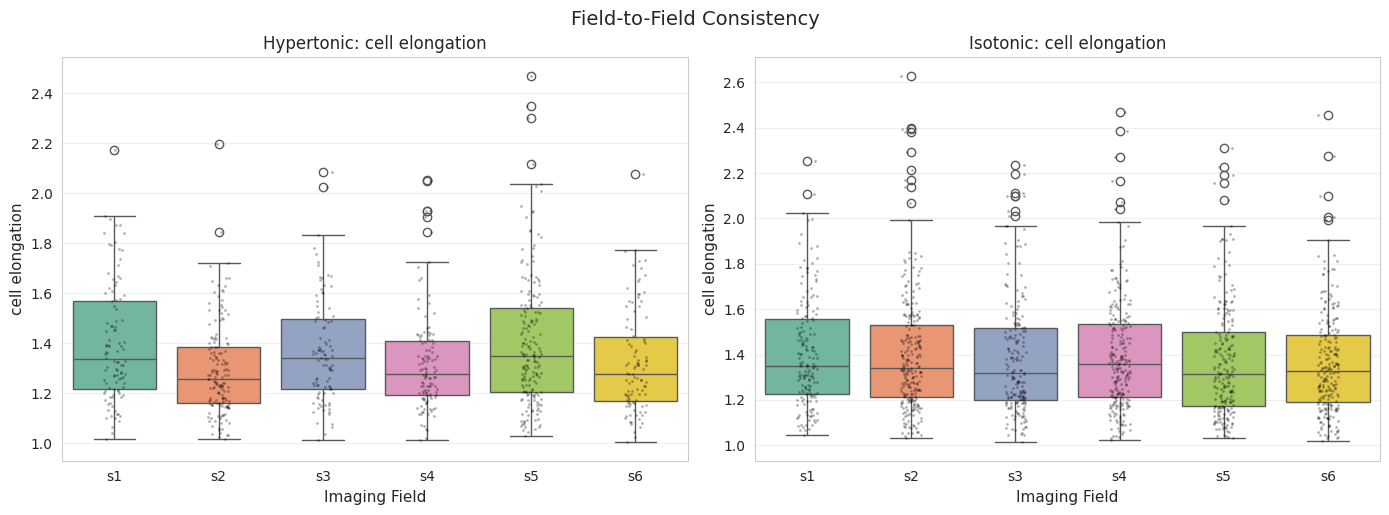

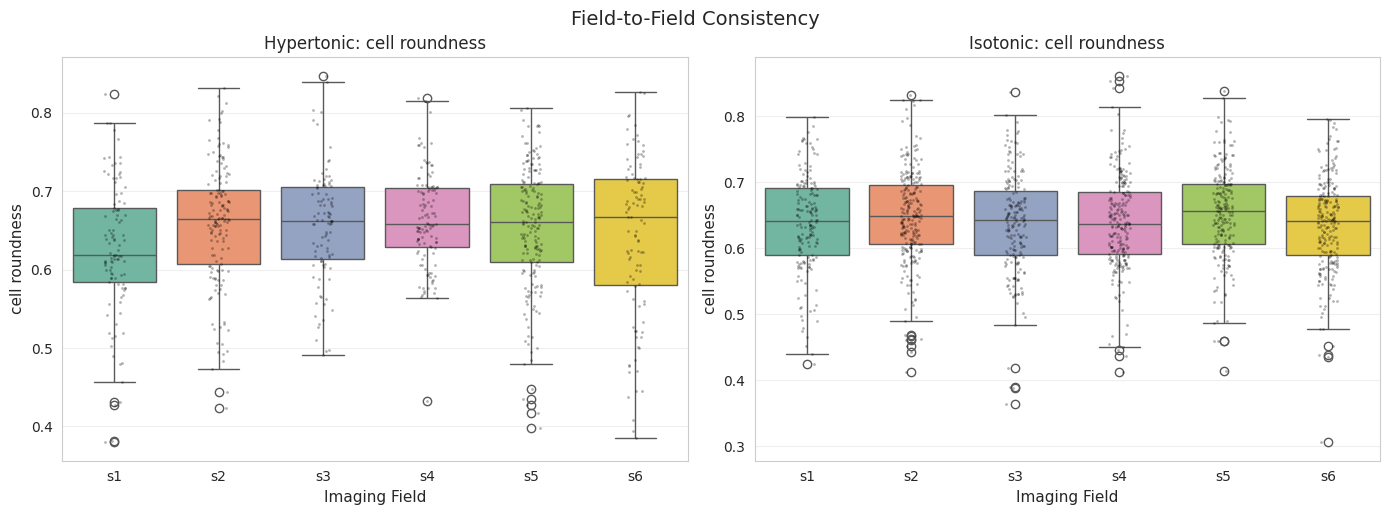

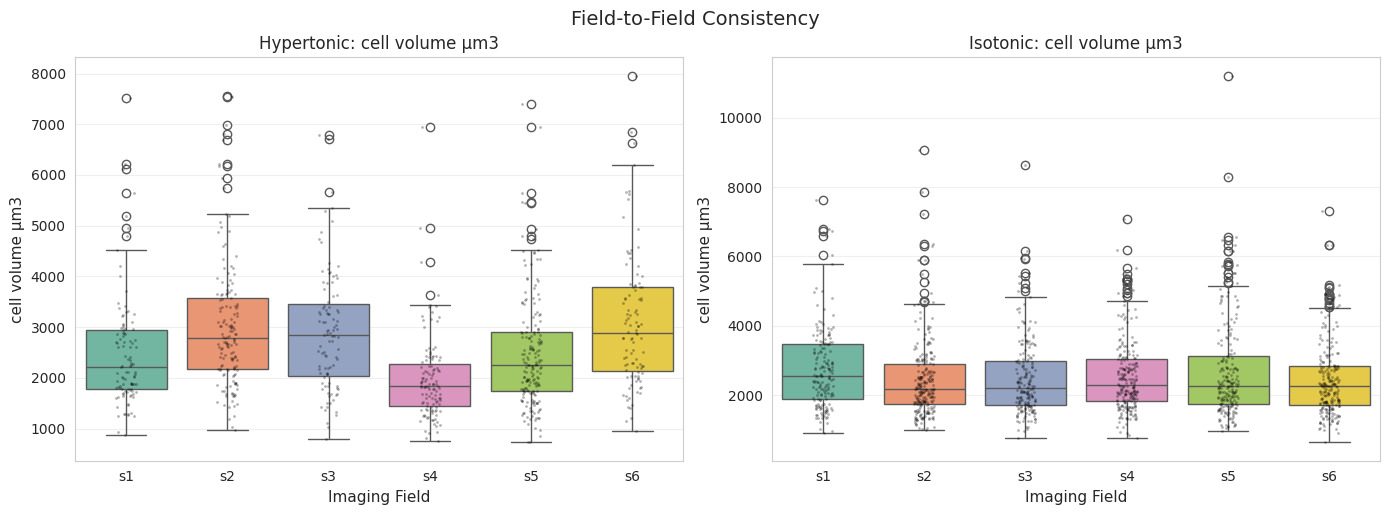

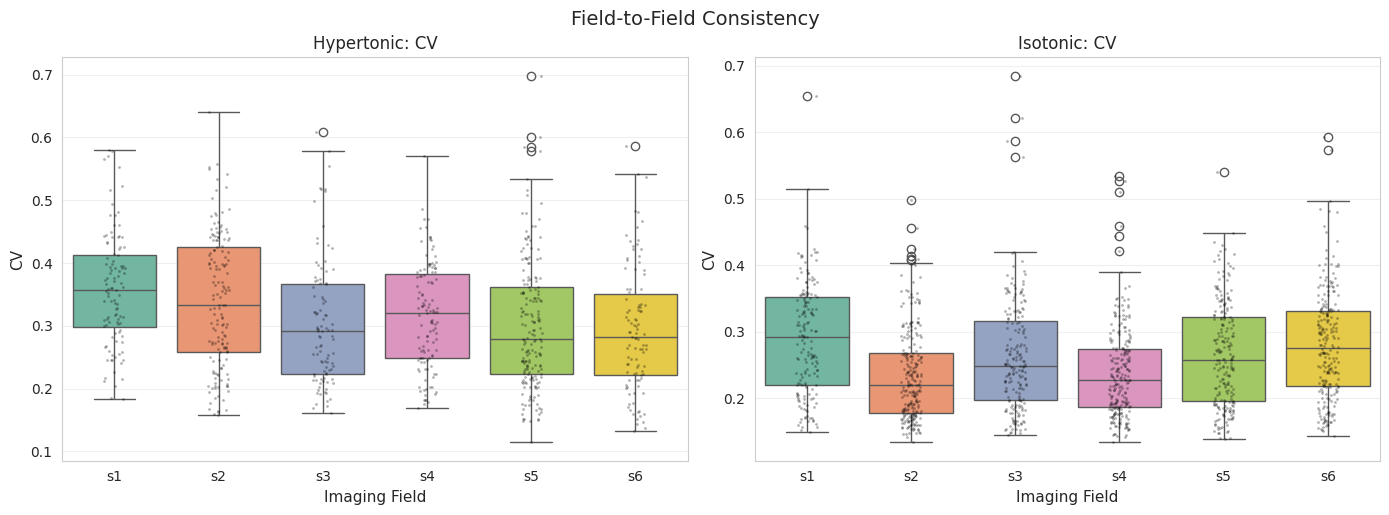

In [ ]:
def plot_field_consistency(df, feature_col, condition_col='Condition', field_col='Field'):
    """
    Plot how a specific feature varies across fields for each condition.

    Args:
        df: DataFrame with data
        feature_col: Feature to plot
        condition_col: Column with condition labels
        field_col: Column with field identifiers
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    conditions = sorted(df[condition_col].unique())

    for idx, condition in enumerate(conditions):
        ax = axes[idx]
        condition_df = df[df[condition_col] == condition]

        # Create box plot per field
        sns.boxplot(data=condition_df, x=field_col, y=feature_col, ax=ax,
                   palette='Set2')
        sns.stripplot(data=condition_df, x=field_col, y=feature_col, ax=ax,
                     color='black', alpha=0.3, size=2)

        feature_name = feature_col.replace('Value of Default_', '').replace('_', ' ')
        ax.set_title(f'{condition}: {feature_name}', fontsize=12)
        ax.set_xlabel('Imaging Field', fontsize=11)
        ax.set_ylabel(feature_name, fontsize=11)
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.suptitle('Field-to-Field Consistency', fontsize=14, y=1.02)
    plt.show()

# Execute: Plot field consistency for each feature
print("\nGenerating field consistency plots for each feature...")
for col in feature_columns:
    plot_field_consistency(df_fig3, col)


### PART 5: RESULTS SUMMARY

Let's create a comprehensive summary of our findings, highlighting the
features that showed the most dramatic changes under osmotic stress.


In [ ]:
def create_results_summary(test_results):
    """
    Create a summary of significant findings with biological interpretation.

    Args:
        test_results: DataFrame with statistical test results
    """
    print(f"\n{'='*70}")
    print("OSMOTIC STRESS EFFECTS: SUMMARY OF FINDINGS")
    print(f"{'='*70}")

    # Filter significant results
    significant = test_results[test_results['Significant_Bonferroni'] == True].copy()
    significant = significant.sort_values('Cohens_d', key=abs, ascending=False)

    print(f"\n✓ Significant features (after Bonferroni correction): {len(significant)} / {len(test_results)}")

    if len(significant) > 0:
        print("\n📊 TOP EFFECTS (sorted by effect size):")
        print("\n" + "─"*70)

        for idx, row in significant.iterrows():
            feature = row['Feature']
            diff = row['Mean_Difference']
            cohens_d = row['Cohens_d']
            p_val = row['P_value']
            effect = row['Effect_Size']

            direction = "increased" if diff > 0 else "decreased"

            print(f"\n{feature}:")
            print(f"  Direction: {direction} in hypertonic")
            print(f"  Effect size: {cohens_d:.3f} ({effect})")
            print(f"  P-value: {p_val:.4e}")

        print("\n" + "─"*70)
    else:
        print("\n⚠ No features reached Bonferroni-corrected significance")
        print("Consider using less conservative correction (e.g., FDR) or examining")
        print("features with uncorrected p < 0.05 and medium-to-large effect sizes.")

    # Features with large effect sizes even if not significant
    large_effects = test_results[abs(test_results['Cohens_d']) > 0.5].copy()
    large_effects = large_effects.sort_values('Cohens_d', key=abs, ascending=False)

    print(f"\n📊 FEATURES WITH MEDIUM-TO-LARGE EFFECTS (|d| > 0.5): {len(large_effects)}")
    if len(large_effects) > 0:
        print(large_effects[['Feature', 'Cohens_d', 'P_value', 'Effect_Size']].to_string(index=False))

# Execute: Create summary
create_results_summary(test_results)


OSMOTIC STRESS EFFECTS: SUMMARY OF FINDINGS

✓ Significant features (after Bonferroni correction): 4 / 5

📊 TOP EFFECTS (sorted by effect size):

──────────────────────────────────────────────────────────────────────

CV:
  Direction: decreased in hypertonic
  Effect size: 0.663 (Medium)
  P-value: 6.9109e-40

cell_elongation:
  Direction: increased in hypertonic
  Effect size: -0.135 (Negligible)
  P-value: 5.9970e-03

cell_roundness:
  Direction: decreased in hypertonic
  Effect size: 0.113 (Negligible)
  P-value: 5.3425e-04

nuclei_dist_to_border_ratio:
  Direction: decreased in hypertonic
  Effect size: 0.081 (Negligible)
  P-value: 1.5540e-04

──────────────────────────────────────────────────────────────────────

📊 FEATURES WITH MEDIUM-TO-LARGE EFFECTS (|d| > 0.5): 1
Feature  Cohens_d      P_value Effect_Size
     CV   0.66337 6.910891e-40      Medium


### PART 6: BIOLOGICAL INTERPRETATION

### OSMOTIC STRESS & CELL MORPHOLOGY

Let's interpret our findings in the biological context of osmotic stress.


---




**1. CELL VOLUME CHANGES**
- Hypertonic medium increases extracellular osmolarity
- Water flows OUT of cells to balance osmotic pressure
- Expected result: DECREASED cell volume
- **Our finding:** No significant volume change detected - cells may regulate volume through ion channels or other mechanisms
- Biological significance: Tests cell volume regulation mechanisms in 3D tissue context

**2. CELL SHAPE CHANGES**
- Volume loss can alter cell roundness and elongation
- Cells may become more compact or irregularly shaped
- Shape changes reflect cytoskeletal reorganization under stress
- **Our finding:** Cells became slightly rounder and less elongated, but effects were negligible in magnitude
- Biological significance: Reveals mechanical properties of 3D tissue and cytoskeletal dynamics

**3. CHROMATIN COMPACTION (CV of DAPI)**
- Osmotic stress often triggers chromatin condensation
- Increased CV = more heterogeneous DAPI staining = more compact regions
- This is a nuclear stress response
- **Our finding:** CV increased dramatically in hypertonic - medium effect size (d = 0.66), highly significant
- Biological significance: Links mechanical stress to nuclear organization

**4. POSITION RELATIVE TO BORDER**
- May change if cells shrink differently based on location
- Border cells vs core cells may respond differently
- **Our finding:** Nuclei shifted slightly toward organoid center
- Biological significance: Reflects mechanical constraints in 3D tissue architecture

---

### KEY BIOLOGICAL INSIGHTS

- Osmotic stress is a mechanical perturbation that cells sense and respond to
- Chromatin compaction is the dominant and most consistent morphological response
- Shape changes are statistically detectable but biologically subtle
- 3D tissue context matters - field-to-field variation reveals spatial heterogeneity
- These measurements capture mechanobiology in action

---

### IMPLICATIONS

- **Mechanobiology:** Understanding how cells sense and respond to mechanical stress in tissue context
- **Disease relevance:** Relevance to conditions with altered osmotic balance (kidney disease, edema, dehydration)
- **Screening applications:** CV as a robust readout for drug screening in mechanically relevant conditions
- **3D biology:** Demonstrates importance of 3D tissue architecture - cells don't respond uniformly
- **Comparison to published findings:** Our results align with Ong et al. (2025) - chromatin compaction is the strongest osmotic stress response

---

## TUTORIAL 3 COMPLETE



**Key point to remember:** Statistical significance doesn't always mean biological importance. Effect sizes matter. CV captured a medium effect (d = 0.66), while shape changes were negligible despite being statistically significant.

---

**Next: Tutorial 4 - Topology + Machine Learning Classification**
- Dataset: Fig-4 (Spatial Organization, 1,784 cells, 8 conditions)
- Goal: Predict sample types from spatial topology features
- Methods: Random Forest, XGBoost, feature importance analysis

---